In [2]:
!pip install tensorflow opencv-python matplotlib textblob nltk


   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/376.0 MB 3.4 MB/s eta 0:01:52
   ---------------------------------------- 1.0/376.0 MB 3.0 MB/s eta 0:02:07
   ---------------------------------------- 2.1/376.0 MB 3.7 MB/s eta 0:01:42
   ---------------------------------------- 3.4/376.0 MB 4.3 MB/s eta 0:01:27
    --------------------------------------- 5.2/376.0 MB 5.2 MB/s eta 0:01:11
    --------------------------------------- 6.0/376.0 MB 5.1 MB/s eta 0:01:14
    --------------------------------------- 8.1/376.0 MB 5.8 MB/s eta 0:01:04
   - -------------------------------------- 11.0/376.0 MB 6.8 MB/s eta 0:00:54
   - -------------------------------------- 13.9/376.0 MB 7.7 MB/s eta 0:00:48
   - -------------------------------------- 18.4/376.0 MB 9.1 MB/s eta 0:00:40
   -- ------------------------------------- 23.9/376.0 MB 10.7 MB/s eta 0:00:33
   -- ------------------------------------- 27.0/376.0 MB 11.2 MB/

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Path to training folder
data_dir = r'C:\Users\Santhoshh\Desktop\fruits_dataset\fruits-360_100x100\fruits-360\Training'

# Image size
img_size = 100

# Prepare data
X = []  # Images
y = []  # Labels
labels = os.listdir(data_dir)

max_images_per_class = 200  # Limit to 200 images per fruit type

for i, label in enumerate(labels):
    path = os.path.join(data_dir, label)
    if not os.path.isdir(path):
        continue

    count = 0
    for img in os.listdir(path):
        if count >= max_images_per_class:
            break
        try:
            img_path = os.path.join(path, img)
            img_array = cv2.imread(img_path)
            img_array = cv2.resize(img_array, (img_size, img_size))
            X.append(img_array)
            y.append(i)
            count += 1
        except:
            pass  # Skip unreadable images

X = np.array(X, dtype='float32') / 255.0  # Normalize images
y = to_categorical(y, num_classes=len(labels))  # One-hot encode labels

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("✅ Data loaded! Shapes:", X_train.shape, y_train.shape)


✅ Data loaded! Shapes: (30875, 100, 100, 3) (30875, 194)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build the CNN model
model = Sequential()

# First convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from the convolutional layers
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer (softmax for multi-class classification)
model.add(Dense(len(labels), activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary to check the architecture
model.summary()


C:\Users\Santhoshh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 194)            │        25,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,756,802 (6.70 MB)

 Trainable params: 1,756,802 (6.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 60s 60ms/step - accuracy: 0.2068 - loss: 3.7135 - val_accuracy: 0.9723 - val_loss: 0.1340
Epoch 2/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.7348 - loss: 0.8280 - val_accuracy: 0.9824 - val_loss: 0.0561
Epoch 3/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.8145 - loss: 0.5615 - val_accuracy: 0.9908 - val_loss: 0.0245
Epoch 4/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.8519 - loss: 0.4284 - val_accuracy: 0.9956 - val_loss: 0.0153
Epoch 5/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.8864 - loss: 0.3363 - val_accuracy: 0.9942 - val_loss: 0.0138
Epoch 6/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.8932 - loss: 0.3027 - val_accuracy: 0.9953 - val_loss: 0.0116
Epoch 7/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.9109 - loss: 0.2577 - val_accuracy: 0.9955 - val_loss: 0.0120
Epoch 8/10
965/965 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.9223 - loss: 0.2252 - 

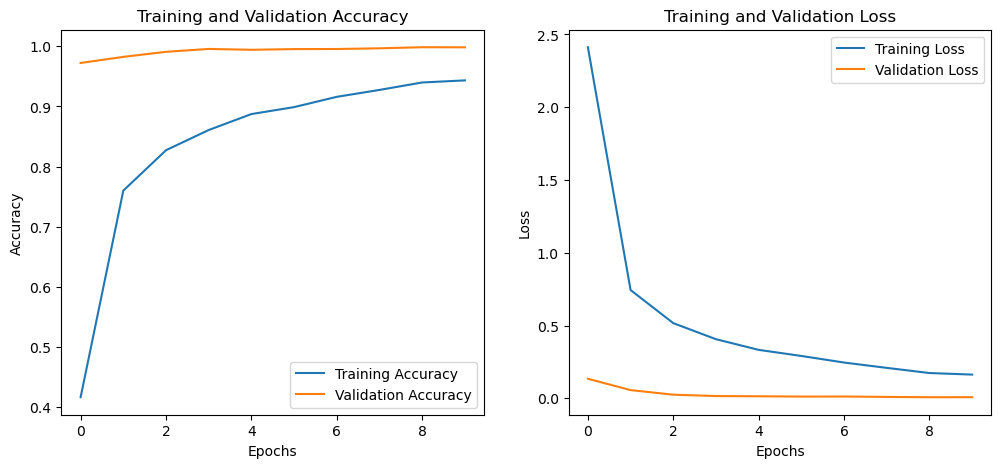

In [17]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [19]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9983 - loss: 0.0069
Test Loss: 0.0074496096931397915
Test Accuracy: 0.9983158707618713


In [21]:
# Save the model
model.save('food_classification_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [54]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model


In [60]:
def predict_image(image_path):
    img = cv2.imread(image_path)  # Read the image from the provided path
    img = cv2.resize(img, (img_size, img_size)) / 255.0  # Resize and normalize the image
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)  # Make the prediction
    
    # Get the label with the highest probability
    predicted_label = np.argmax(prediction)
    
    # Map the predicted label back to the food name
    food_type = labels[predicted_label]
    return food_type

# Example: Predict food type for the downloaded image
image_path = 'C:/Users/Santhoshh/Desktop/banana1.jpeg'  # Make sure the image is at this path
food_type = predict_image(image_path)
print(f"The predicted food type is: {food_type}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted food type is: Banana Red 1
